In [1]:
from time_series_gan.WGAN import WGAN
import numpy as np
import pandas as pd
from time_series_gan.metrics import dWasserstein, dFrechet, ONND, score
from Optimisation_MH import generer_resultats, Metropolis_Hasting

c:\Users\sducr\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data = pd.read_csv("data/synthetic_data.csv")
archi = Metropolis_Hasting(0.1, data, WGAN, ite = 1000, metrique=score, nom_de_la_métrique = "score")

fit took 16.542804 seconds
MH étape : 0
suppression d'une couche du critic
fit took 12.522637 seconds
echec


MH étape : 1
modification des paramètres
fit took 3.963340 seconds
echec


MH étape : 2
modification des paramètres
fit took 15.571131 seconds
echec


MH étape : 3
modification des paramètres
fit took 10.435511 seconds
echec


MH étape : 4
modification des paramètres
fit took 10.265135 seconds
succes
3.8026539990671324 ->  3.6886608606126763

{'lr_g': 0.001374, 'lr_c': 0.001045, 'epochs': 150, 'batch_size': 49, 'latent_dim': 33, 'n_critic': 1, 'lambda_gp': 0.1289}
generator : [1]        ReLU
critic : [1]        ReLU


MH étape : 5
modification des paramètres
fit took 10.885689 seconds
echec


MH étape : 6
suppression d'une couche du critic
fit took 14.392588 seconds
echec


MH étape : 7
ajout d'une couche au critic
fit took 13.113494 seconds
echec


MH étape : 8
suppression d'une couche du generator
fit took 11.178983 seconds
echec


MH étape : 9
modification de la fonction d'a

In [5]:
params = {'lr_g': 0.003741, 'lr_c': 0.001706, 'epochs': 150, 'batch_size': 35, 'latent_dim': 94, 'n_critic': 2, 'lambda_gp': 0.4408}
print(archi)

{'generator': {'architecture': 'MLP', 'layer_sizes': [73, 1], 'activation': Tanh()}, 'critic': {'architecture': 'MLP', 'layer_sizes': [63, 53, 67, 1], 'activation': Sigmoid()}}


Epoch [1/150], C Loss: 0.4676, G Loss: 0.2079, Dwasserstein: 0.8561, Dfrechet: 1.6630, Onnd: 0.1485, Score: 11.5191
Epoch [2/150], C Loss: -0.2800, G Loss: 0.4872, Dwasserstein: 0.2922, Dfrechet: 1.7908, Onnd: 0.0856, Score: 4.5350
Epoch [3/150], C Loss: 0.2673, G Loss: -0.2864, Dwasserstein: 0.8065, Dfrechet: 2.2027, Onnd: 0.0696, Score: 11.8928
Epoch [4/150], C Loss: -0.2724, G Loss: 1.2450, Dwasserstein: 0.4720, Dfrechet: 1.6910, Onnd: 0.0394, Score: 7.4300
Epoch [5/150], C Loss: -0.0440, G Loss: 0.4242, Dwasserstein: 0.4037, Dfrechet: 1.8843, Onnd: 0.0610, Score: 4.0759
Epoch [6/150], C Loss: 0.0793, G Loss: 0.9563, Dwasserstein: 0.2548, Dfrechet: 1.6275, Onnd: 0.0357, Score: 4.0406
Epoch [7/150], C Loss: -0.2298, G Loss: 0.4742, Dwasserstein: 0.2912, Dfrechet: 1.7728, Onnd: 0.1306, Score: 5.0779
Epoch [8/150], C Loss: -0.4146, G Loss: 0.2523, Dwasserstein: 0.2171, Dfrechet: 2.3393, Onnd: 0.0634, Score: 3.1579
Epoch [9/150], C Loss: -0.1306, G Loss: 0.8416, Dwasserstein: 0.3299, Df

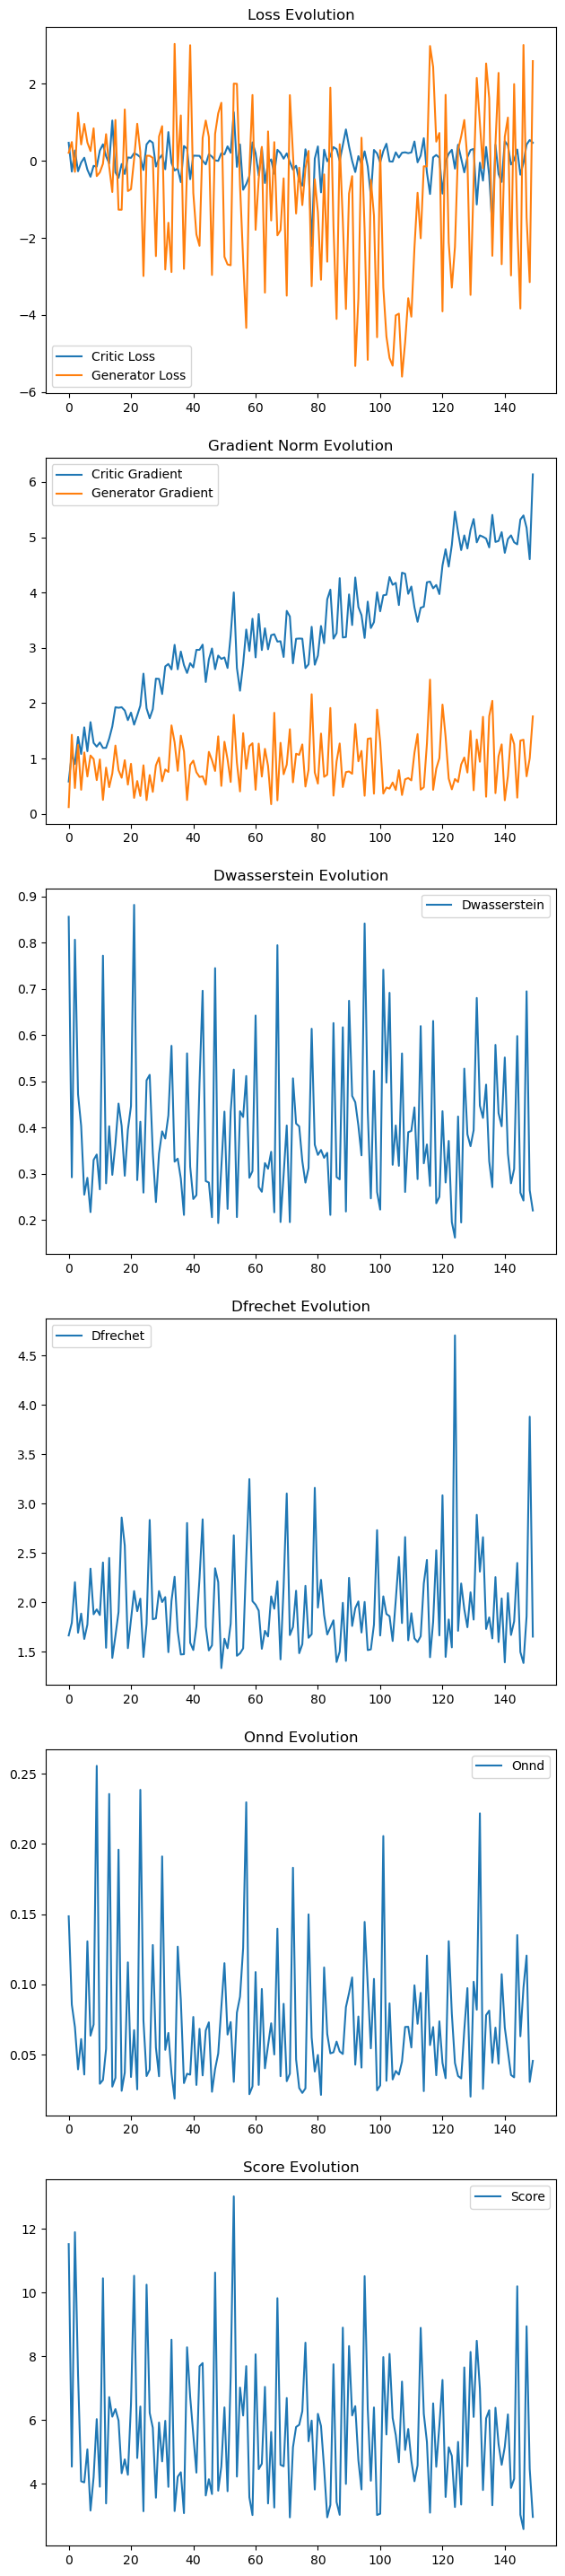

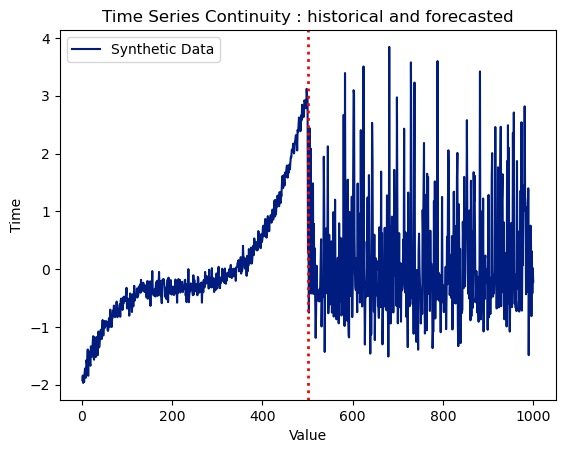

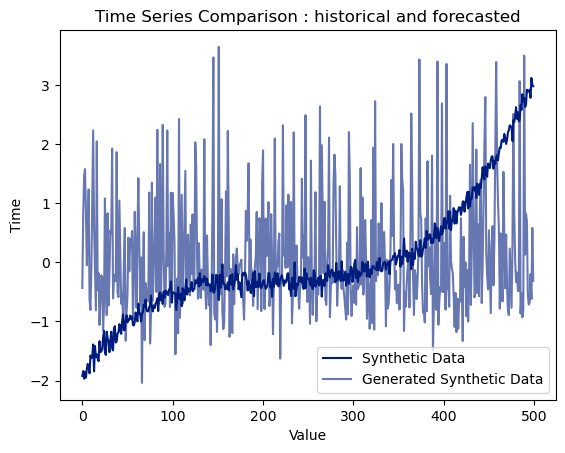

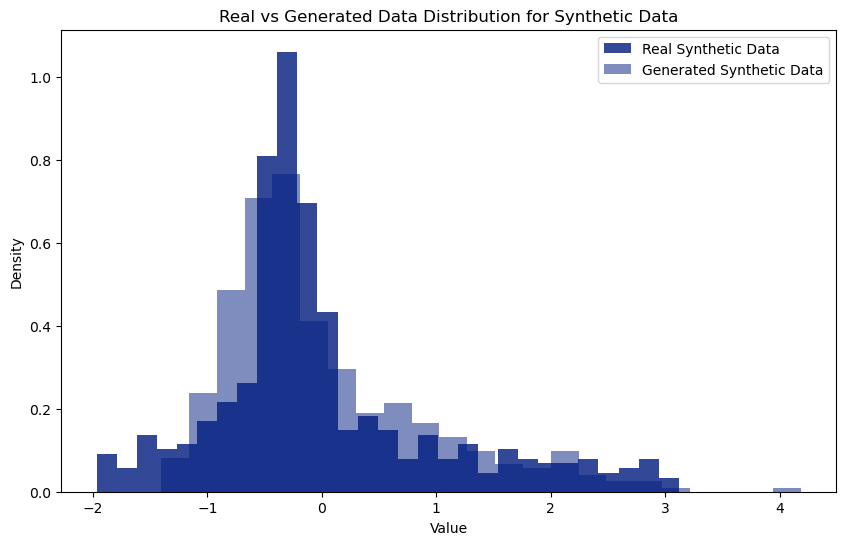

fit took 219.096714 seconds


{'dWasserstein': (0.20744684778821934, 0.19159955728113506),
 'dFrechet': (1.852678011808428, 1.5780579545856992),
 'ONND': (0.007568898753232324, 0.030571400759068293),
 'score': (2.9579035290881355, 3.0618052233508313)}

In [6]:
model = WGAN()
model.set_data(data)
model.set_metrics({'dWasserstein': {'function':dWasserstein, 'metric_args': {}}, 'dFrechet': {'function':dFrechet, 'metric_args': {}}, 'ONND': {'function':ONND, 'metric_args': {}}, 'score': {'function':score, 'metric_args': {}}})
model.fit(architectures = archi, params = params, verbose = True)

In [7]:
n = 20

w = np.array([model.compute_val_metric(dWasserstein, {}) for _ in range(n)])
print("Wasserstein", w.mean(), w.std())

f = np.array([model.compute_val_metric(dFrechet, {}) for _ in range(n)])
print("Fréchet", f.mean(), f.std())

o = np.array([model.compute_val_metric(ONND, {}) for _ in range(n)])
print("ONND", o.mean(), o.std())

s = np.array([model.compute_val_metric(score, {}) for _ in range(n)])
print("Score", s.mean(), s.std())

Wasserstein 0.20324516525485978 0.02411349676755109
Fréchet 1.6584514435223032 0.3570993439144693
ONND 0.041210500251864485 0.009875438168820756
Score 3.56412070938575 0.7274385729445766


In [ ]:
model.fit_hyperparameters({"lr_g": [5e-6, 5e-3], "lr_d": [5e-6, 5e-3], "epochs": [50, 150], "batch_size": [8,300], "latent_dim": [1,150], "n_critic" : [1, 5], "lambda_gp" : [0.01, 0.5]}, n_trials = 100)

{'lr_g': 1e-05, 'lr_c': 1e-05, 'epochs': 100, 'batch_size': 32, 'latent_dim': 100, 'n_critic': 2, 'lambda_gp': 0.1}


In [5]:
print(model.parameters)

{'lr_g': 0.0007500669017475796, 'lr_d': 0.004051898971486163, 'epochs': 146, 'batch_size': 80, 'latent_dim': 138}


Epoch [1/146], C Loss: 1.7231, G Loss: 0.6396, 
Epoch [2/146], C Loss: 1.3946, G Loss: 0.6578, 
Epoch [3/146], C Loss: 1.4140, G Loss: 0.7836, 
Epoch [4/146], C Loss: 1.4655, G Loss: 0.8173, 
Epoch [5/146], C Loss: 1.3686, G Loss: 0.8447, 
Epoch [6/146], C Loss: 1.2868, G Loss: 0.7301, 
Epoch [7/146], C Loss: 1.4725, G Loss: 0.7378, 
Epoch [8/146], C Loss: 1.4528, G Loss: 0.9697, 
Epoch [9/146], C Loss: 1.3295, G Loss: 0.6089, 
Epoch [10/146], C Loss: 1.3118, G Loss: 0.8197, 
Epoch [11/146], C Loss: 1.3372, G Loss: 0.6670, 
Epoch [12/146], C Loss: 1.3471, G Loss: 0.7007, 
Epoch [13/146], C Loss: 1.3090, G Loss: 0.7564, 
Epoch [14/146], C Loss: 1.3981, G Loss: 0.8059, 
Epoch [15/146], C Loss: 1.3200, G Loss: 0.6252, 
Epoch [16/146], C Loss: 1.3611, G Loss: 0.8091, 
Epoch [17/146], C Loss: 1.4830, G Loss: 0.7505, 
Epoch [18/146], C Loss: 1.2827, G Loss: 0.7322, 
Epoch [19/146], C Loss: 1.2485, G Loss: 0.9346, 
Epoch [20/146], C Loss: 1.4347, G Loss: 0.8924, 
Epoch [21/146], C Loss: 1.320

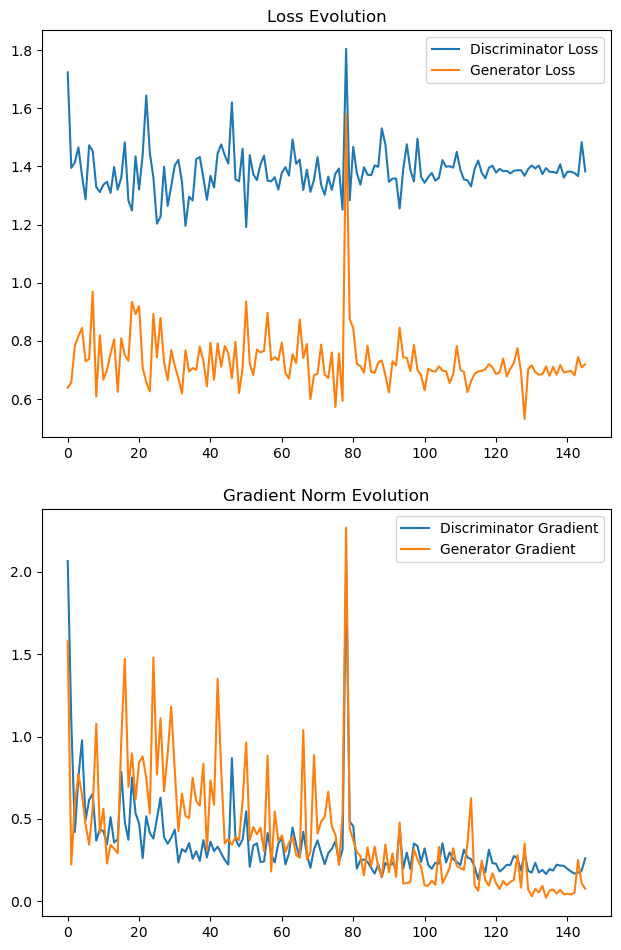

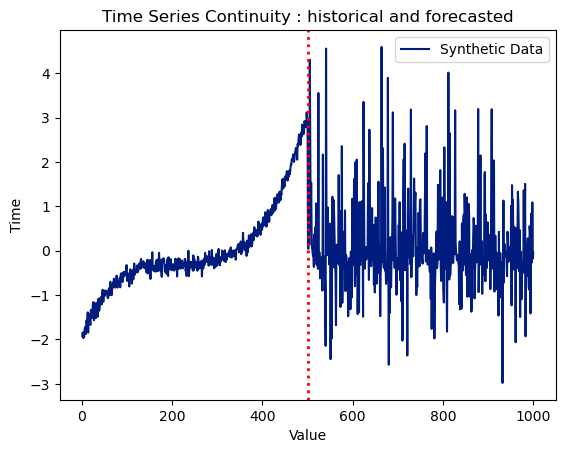

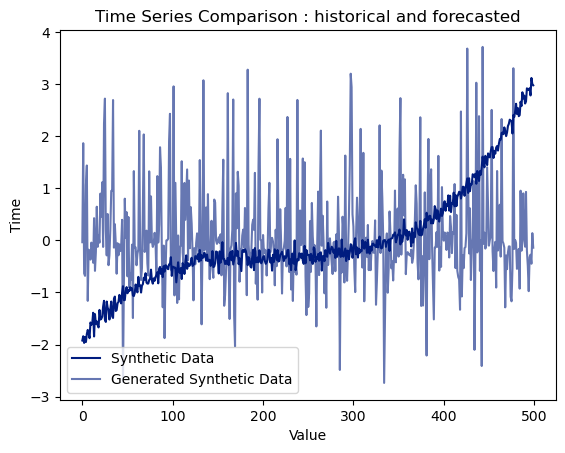

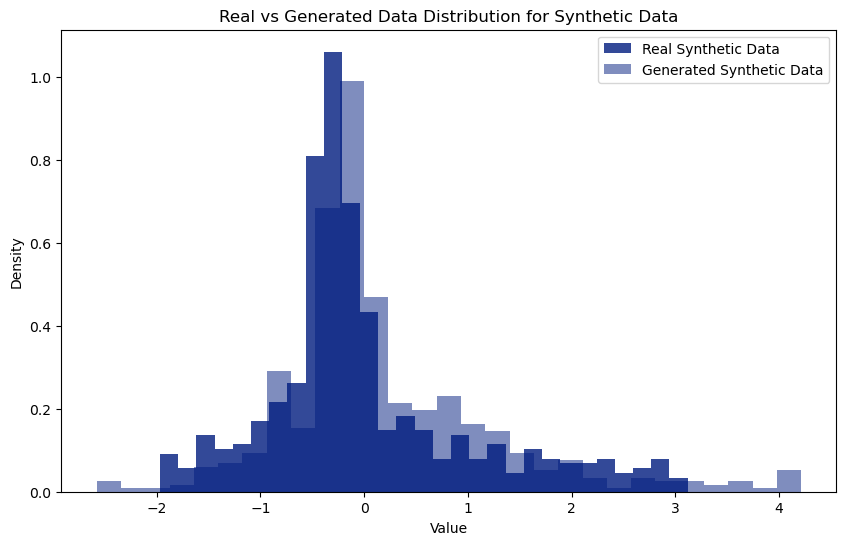

fit took 23.103918 seconds


{}

In [11]:
model.fit(verbose = True)

In [12]:
n = 30

w = [model.compute_val_metric(dWasserstein, {}) for _ in range(n)]
f = [model.compute_val_metric(dFrechet, {}) for _ in range(n)]
o = [model.compute_val_metric(ONND, {}) for _ in range(n)]
s = [model.compute_val_metric(score, {}) for _ in range(n)]

print("Wasserstein", sum(w)/n)
print("Fréchet", sum(f)/n)
print("ONND", sum(o)/n)
print("Score", sum(s)/n)

Wasserstein 0.20396893394985302
Fréchet 2.233898550939729
ONND 0.02739973495337883
Score 3.491170696430067
